In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
WITH_SERVICE_AUTHENTICATION = 'WITH_SERVICE_AUTHENTICATION'
WITH_CLIENT_AUTHENTICATION = 'WITH_CLIENT_AUTHENTICATION'
NO_SOMEIP_SD = 'NO_SOMEIP_SD'
WITH_DNSSEC = 'WITH_DNSSEC'
WITH_DANE = 'WITH_DANE'
WITH_ENCRYPTION = 'WITH_ENCRYPTION'

STATISTICS_PARENT_PATH='/home/vm-user/workspace/mininet-vsomeip-evaluation/statistic-results' # VM
# STATISTICS_PARENT_PATH='C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\statistic-results' # Philipp 
# STATISTICS_PARENT_PATH='C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\statistic-results-no-debug-log' # Philipp 
# STATISTICS_PARENT_PATH='C:\\Users\\Timo\\OneDrive\\Documents\\Uni\\Promotion\\Paper\\241001_DNSSEC_AuthO\\data\\statistic-results-new-stats' # Timo 

compile_definitions = { 'A':'Vanilla',
                        # 'B':f'{NO_SOMEIP_SD} {WITH_DNSSEC}',
                        # 'C':f'{WITH_SERVICE_AUTHENTICATION}',
                        # 'D':f'{NO_SOMEIP_SD} {WITH_SERVICE_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE}',
                        # 'E':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION}',
                        'F':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_ENCRYPTION}',
                        # 'G':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE}',
                        'H':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE} {WITH_ENCRYPTION}'}

# Carnet

In [23]:
STATISTICS_PARENT_PATH='/home/vm-user/workspace/mininet-vsomeip-evaluation/carnet/statistic-results' # VM
# STATISTICS_PARENT_PATH='C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\statistic-results' # Philipp 
# STATISTICS_PARENT_PATH='C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\statistic-results-no-debug-log' # Philipp 
# STATISTICS_PARENT_PATH='C:\\Users\\Timo\\OneDrive\\Documents\\Uni\\Promotion\\Paper\\241001_DNSSEC_AuthO\\data\\statistic-results-new-stats' # Timo 

## Read Data

In [24]:
series = dict()
for option, description in compile_definitions.items():
	resultpath = f'{STATISTICS_PARENT_PATH}/{option}-series/'
	# get all files in the resultpath
	resultfilepaths = list(Path(resultpath).rglob('*.csv'))
	# map for runs
	series[option] = dict()
	for filepath in resultfilepaths:
		# Get filename
		filename = filepath.name
		# Get run number
		run_number = int(filename.split('-')[2].split('.')[0].replace('#', ''))
		# Create new dict if not exists
		if run_number not in series[option]:
			series[option][run_number] = dict()
		# Get service id
		service_id = int(filename.split('-')[1])
		# Read csv
		series[option][run_number][service_id] = pd.read_csv(filepath, header=0, sep=',', dtype=np.longlong)


## Select Data

In [ ]:
OPTION = 'ALL'
RUN = 'ALL'
# SERVICE_ID = 300
SERVICE_ID = 'ALL'
total_startup = dict()

def calc_latencies(series, option, run, service_id):
	df = series[option][run][service_id]
	description = compile_definitions[option]
	if NO_SOMEIP_SD in description:
		subscription_start = df['SVCB_SERVICE_RESPONSE_RECEIVE']
	else:
		subscription_start = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1))
	if WITH_SERVICE_AUTHENTICATION in description:
		subscription_end= df['VERIFY_SERVICE_SIGNATURE_END']
	else:
		subscription_end = df['SUBSCRIBE_ACK_RECEIVE']
	# first_offer_to_first_validation
	df['FIRST_OFFER_TO_FIRST_VALIDATION'] = df['VALIDATE_OFFER_START'] - df['OFFER_RECEIVE']
	# setup_delay
	df['SETUP_DELAY'] = subscription_end - df['OFFER_RECEIVE']
	# offer_reaction_time
	df['OFFER_REACTION_TIME'] = df['SUBSCRIBE_SEND'] - df['OFFER_RECEIVE']
	# subscribe_reaction_time
	df['SUBSCRIBE_REACTION_TIME'] = df['SUBSCRIBE_ACK_SEND'] - df['SUBSCRIBE_RECEIVE']
	# subscribe_ack_reaction_time
	df['SUBSCRIBE_ACK_REACTION_TIME'] = subscription_end - df['SUBSCRIBE_ACK_RECEIVE']
	# dsn_resolution_time
	df['DSN_RESOLUTION_TIME_SVCB'] = df['SVCB_SERVICE_RESPONSE_RECEIVE'] - df['SVCB_SERVICE_REQUEST_SEND']
	df['DSN_RESOLUTION_TIME_TLSA_CLIENT'] = df['TLSA_CLIENT_RESPONSE_RECEIVE'] - df['TLSA_CLIENT_REQUEST_SEND']
	df['DSN_RESOLUTION_TIME_TLSA_SERVICE'] = df['TLSA_SERVICE_RESPONSE_RECEIVE'] - df['TLSA_SERVICE_REQUEST_SEND']
	# crypto_operations_time
	df['CRYPTO_OPERATIONS_TIME_GENERATE_OFFER_NONCE'] = df['GENERATE_OFFER_NONCE_END'] - df['GENERATE_OFFER_NONCE_START']
	df['CRYPTO_OPERATIONS_TIME_VALIDATE_OFFER'] = df['VALIDATE_OFFER_END'] - df['VALIDATE_OFFER_START']
	df['CRYPTO_OPERATIONS_TIME_CLIENT_SIGN'] = df['CLIENT_SIGN_END'] - df['CLIENT_SIGN_START']
	df['CRYPTO_OPERATIONS_TIME_VERIFY_CLIENT_SIGNATURE'] = df['VERIFY_CLIENT_SIGNATURE_END'] - df['VERIFY_CLIENT_SIGNATURE_START']
	df['CRYPTO_OPERATIONS_TIME_SERVICE_SIGN'] = df['SERVICE_SIGN_END'] - df['SERVICE_SIGN_START']
	df['CRYPTO_OPERATIONS_TIME_VERIFY_SERVICE_SIGNATURE'] = df['VERIFY_SERVICE_SIGNATURE_END'] - df['VERIFY_SERVICE_SIGNATURE_START']
	return subscription_end

if OPTION == 'ALL' and RUN == 'ALL' and SERVICE_ID == 'ALL':
	for option in sorted(series):
		if option not in total_startup:
			total_startup[option] = dict()
		for run in sorted(series[option]):
			if run not in total_startup[option]:
				total_startup[option][run] = dict()
				total_startup[option][run]['OFFER_RECEIVE_MIN'] = np.inf
				total_startup[option][run]['SUBSCRIPTION_END_MAX'] = 0
			for service_id in sorted(series[option][run]):
				subscription_end = calc_latencies(series, option, run, service_id)
				total_startup[option][run]['OFFER_RECEIVE_MIN'] = min(total_startup[option][run]['OFFER_RECEIVE_MIN'], series[option][run][service_id]['OFFER_RECEIVE'].min())
				total_startup[option][run]['SUBSCRIPTION_END_MAX'] = max(total_startup[option][run]['SUBSCRIPTION_END_MAX'], subscription_end.max())
				# progressbar animation
				print(f'\r{option} {run} {service_id}      ', end='')
			total_startup[option][run]['TOTAL_STARTUP_TIME'] = total_startup[option][run]['SUBSCRIPTION_END_MAX'] - total_startup[option][run]['OFFER_RECEIVE_MIN']
	for option in sorted(series):
		# Open txt file for writing
		with open(f'{STATISTICS_PARENT_PATH}/{option}-statistics.txt', 'w') as f:
			all_first_offer_to_first_validation = []
			all_setup_delay = []
			all_offer_reaction_time = []
			all_subscribe_reaction_time = []
			all_subscribe_ack_reaction_time = []
			all_dsn_resolution_time_svcb = []
			all_dsn_resolution_time_tlsa_client = []
			all_dsn_resolution_time_tlsa_service = []
			all_crypto_operations_time_generate_offer_nonce = []
			all_crypto_operations_time_validate_offer = []
			all_crypto_operations_time_client_sign = []
			all_crypto_operations_time_verify_client_signature = []
			all_crypto_operations_time_service_sign = []
			all_crypto_operations_time_verify_service_signature = []
			all_crypto_operations_time_create_signature = []
			all_crypto_operations_time_verify_signature = []
			all_total_startup_time = []
			for run in sorted(series[option]):		
				for service_id in sorted(series[option][run]):
					all_first_offer_to_first_validation.extend(series[option][run][service_id]['FIRST_OFFER_TO_FIRST_VALIDATION'].values / 1000_000)
					all_setup_delay.extend(series[option][run][service_id]['SETUP_DELAY'].values / 1000_000)
					all_offer_reaction_time.extend(series[option][run][service_id]['OFFER_REACTION_TIME'].values / 1000_000)
					all_subscribe_reaction_time.extend(series[option][run][service_id]['SUBSCRIBE_REACTION_TIME'].values / 1000_000)
					all_subscribe_ack_reaction_time.extend(series[option][run][service_id]['SUBSCRIBE_ACK_REACTION_TIME'].values / 1000_000)
					all_dsn_resolution_time_svcb.extend(series[option][run][service_id]['DSN_RESOLUTION_TIME_SVCB'].values / 1000_000)
					all_dsn_resolution_time_tlsa_client.extend(series[option][run][service_id]['DSN_RESOLUTION_TIME_TLSA_CLIENT'].values / 1000_000)
					all_dsn_resolution_time_tlsa_service.extend(series[option][run][service_id]['DSN_RESOLUTION_TIME_TLSA_SERVICE'].values / 1000_000)
					all_crypto_operations_time_generate_offer_nonce.extend(series[option][run][service_id]['CRYPTO_OPERATIONS_TIME_GENERATE_OFFER_NONCE'].values / 1000_000)
					all_crypto_operations_time_validate_offer.extend(series[option][run][service_id]['CRYPTO_OPERATIONS_TIME_VALIDATE_OFFER'].values / 1000_000)
					all_crypto_operations_time_client_sign.extend(series[option][run][service_id]['CRYPTO_OPERATIONS_TIME_CLIENT_SIGN'].values / 1000_000)
					all_crypto_operations_time_verify_client_signature.extend(series[option][run][service_id]['CRYPTO_OPERATIONS_TIME_VERIFY_CLIENT_SIGNATURE'].values / 1000_000)
					all_crypto_operations_time_service_sign.extend(series[option][run][service_id]['CRYPTO_OPERATIONS_TIME_SERVICE_SIGN'].values / 1000_000)
					all_crypto_operations_time_verify_service_signature.extend(series[option][run][service_id]['CRYPTO_OPERATIONS_TIME_VERIFY_SERVICE_SIGNATURE'].values / 1000_000)
				all_total_startup_time.extend([total_startup[option][run]['TOTAL_STARTUP_TIME'] / 1000_000])
			# joint lists for all_crypto_operations_time_create_signature from all_crypto_operations_time_service_sign and all_crypto_operations_time_client_sign
			all_crypto_operations_time_create_signature = all_crypto_operations_time_service_sign + all_crypto_operations_time_client_sign
			# joint lists for all_crypto_operations_time_verify_signature from all_crypto_operations_time_verify_service_signature and all_crypto_operations_time_verify_client_signature
			all_crypto_operations_time_verify_signature = all_crypto_operations_time_verify_service_signature + all_crypto_operations_time_verify_client_signature
			f.write(f"First Offer to First Validation - Min: {np.min(all_first_offer_to_first_validation)}, Mean: {np.mean(all_first_offer_to_first_validation)}, Max: {np.max(all_first_offer_to_first_validation)}\n")
			f.write(f"Setup Delay - Min: {np.min(all_setup_delay)}, Mean: {np.mean(all_setup_delay)}, Max: {np.max(all_setup_delay)}\n")
			f.write(f"Offer Reaction Time - Min: {np.min(all_offer_reaction_time)}, Mean: {np.mean(all_offer_reaction_time)}, Max: {np.max(all_offer_reaction_time)}\n")
			f.write(f"Subscribe Reaction Time - Min: {np.min(all_subscribe_reaction_time)}, Mean: {np.mean(all_subscribe_reaction_time)}, Max: {np.max(all_subscribe_reaction_time)}\n")
			f.write(f"Subscribe Ack Reaction Time - Min: {np.min(all_subscribe_ack_reaction_time)}, Mean: {np.mean(all_subscribe_ack_reaction_time)}, Max: {np.max(all_subscribe_ack_reaction_time)}\n")
			f.write(f"DNS Resolution Time SVCB - Min: {np.min(all_dsn_resolution_time_svcb)}, Mean: {np.mean(all_dsn_resolution_time_svcb)}, Max: {np.max(all_dsn_resolution_time_svcb)}\n")
			f.write(f"DNS Resolution Time TLSA Client - Min: {np.min(all_dsn_resolution_time_tlsa_client)}, Mean: {np.mean(all_dsn_resolution_time_tlsa_client)}, Max: {np.max(all_dsn_resolution_time_tlsa_client)}\n")
			f.write(f"DNS Resolution Time TLSA Service - Min: {np.min(all_dsn_resolution_time_tlsa_service)}, Mean: {np.mean(all_dsn_resolution_time_tlsa_service)}, Max: {np.max(all_dsn_resolution_time_tlsa_service)}\n")
			f.write(f"Crypto Operations Time Generate Offer Nonce - Min: {np.min(all_crypto_operations_time_generate_offer_nonce)}, Mean: {np.mean(all_crypto_operations_time_generate_offer_nonce)}, Max: {np.max(all_crypto_operations_time_generate_offer_nonce)}\n")
			f.write(f"Crypto Operations Time Validate Offer - Min: {np.min(all_crypto_operations_time_validate_offer)}, Mean: {np.mean(all_crypto_operations_time_validate_offer)}, Max: {np.max(all_crypto_operations_time_validate_offer)}\n")
			f.write(f"Crypto Operations Time Client Sign - Min: {np.min(all_crypto_operations_time_client_sign)}, Mean: {np.mean(all_crypto_operations_time_client_sign)}, Max: {np.max(all_crypto_operations_time_client_sign)}\n")
			f.write(f"Crypto Operations Time Verify Client Signature - Min: {np.min(all_crypto_operations_time_verify_client_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_client_signature)}, Max: {np.max(all_crypto_operations_time_verify_client_signature)}\n")
			f.write(f"Crypto Operations Time Service Sign - Min: {np.min(all_crypto_operations_time_service_sign)}, Mean: {np.mean(all_crypto_operations_time_service_sign)}, Max: {np.max(all_crypto_operations_time_service_sign)}\n")
			f.write(f"Crypto Operations Time Verify Service Signature - Min: {np.min(all_crypto_operations_time_verify_service_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_service_signature)}, Max: {np.max(all_crypto_operations_time_verify_service_signature)}\n")
			f.write(f"Crypto Operations Time Create All Signature - Min: {np.min(all_crypto_operations_time_create_signature)}, Mean: {np.mean(all_crypto_operations_time_create_signature)}, Max: {np.max(all_crypto_operations_time_create_signature)}\n")
			f.write(f"Crypto Operations Time Verify All Signature - Min: {np.min(all_crypto_operations_time_verify_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_signature)}, Max: {np.max(all_crypto_operations_time_verify_signature)}\n")
			f.write(f"Total Startup Time - Min: {np.min(all_total_startup_time)}, Mean: {np.mean(all_total_startup_time)}, Max: {np.max(all_total_startup_time)}\n")
elif RUN == 'ALL':
	first_offer_to_first_validation_min_list = list()
	first_offer_to_first_validation_mean_list = list()
	first_offer_to_first_validation_max_list = list()
	a_placeholder_list = list()
	for run in sorted(series[OPTION]):
		calc_latencies(series, OPTION, run, SERVICE_ID)
		first_offer_to_first_validation_min_list.append(series[OPTION][run][SERVICE_ID]['FIRST_OFFER_TO_FIRST_VALIDATION'].min()/1000_000)
		first_offer_to_first_validation_mean_list.append(series[OPTION][run][SERVICE_ID]['FIRST_OFFER_TO_FIRST_VALIDATION'].mean()/1000_000)
		first_offer_to_first_validation_max_list.append(series[OPTION][run][SERVICE_ID]['FIRST_OFFER_TO_FIRST_VALIDATION'].max()/1000_000)
		a_placeholder_list.append(series[OPTION][run][SERVICE_ID]['SETUP_DELAY'].min()/1000_000)
	print(a_placeholder_list)
	print(np.min(a_placeholder_list))
	print(np.mean(a_placeholder_list))
	print(np.max(a_placeholder_list))
else:
	calc_latencies(series, OPTION, RUN, SERVICE_ID)


H 24 7013

# Scalability

In [3]:
WITH_SERVICE_AUTHENTICATION = 'WITH_SERVICE_AUTHENTICATION'
WITH_CLIENT_AUTHENTICATION = 'WITH_CLIENT_AUTHENTICATION'
NO_SOMEIP_SD = 'NO_SOMEIP_SD'
WITH_DNSSEC = 'WITH_DNSSEC'
WITH_DANE = 'WITH_DANE'
WITH_ENCRYPTION = 'WITH_ENCRYPTION'

STATISTICS_PARENT_PATH='/home/vm-user/workspace/mininet-vsomeip-evaluation/statistic-results' # VM
# STATISTICS_PARENT_PATH='C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\scalability-study\\measurement-new-stats' # Philipp 
# STATISTICS_PARENT_PATH='C:\\Users\\Timo\\OneDrive\\Documents\\Uni\\Promotion\\Paper\\241001_DNSSEC_AuthO\\data\\scalability-study\\measurement-new-stats' # Timo 
# STATISTICS_PARENT_PATH='C:\\Users\\Timo\\OneDrive\\Documents\\Uni\\Promotion\\Paper\\241001_DNSSEC_AuthO\\data\\scalability-study\\old-study' # Timo 

compile_definitions = { 'A':'Vanilla',
                        # 'B':f'{NO_SOMEIP_SD} {WITH_DNSSEC}',
                        # 'C':f'{WITH_SERVICE_AUTHENTICATION}',
                        # 'D':f'{NO_SOMEIP_SD} {WITH_SERVICE_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE}',
                        # 'E':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION}',
                        'F':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_ENCRYPTION}',
                        # 'G':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE}',
                        'H':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE} {WITH_ENCRYPTION}'}

## Read data

In [4]:
scalability_series = dict()
for option, description in compile_definitions.items():
	resultpath = f'{STATISTICS_PARENT_PATH}/{option}-series/'
	# get all files in the resultpath
	resultfilepaths = list(Path(resultpath).rglob('*.csv'))
	# map for runs
	scalability_series[option] = dict()
	for filepath in resultfilepaths:
		# Get filename
		filename = filepath.name
		# Get run number
		run_number = int(filename.split('#')[-1].split('.')[0])
		# Get sub count
		sub_count = int(filename.split('-')[1])
		# Create new dict if not exists
		if sub_count not in scalability_series[option]:
			scalability_series[option][sub_count] = dict()
		# progressbar animation
		print(f'\r{option} {sub_count} {run_number}            ', end='')
		# Read csv
		scalability_series[option][sub_count][run_number] = pd.read_csv(filepath, header=0, sep=',', dtype=np.longlong)



H 1 4             

## Select data

In [ ]:
OPTION = 'ALL'
RUN = 'ALL'
# SERVICE_ID = 300
SUB_COUNT = 'ALL'
total_startup_scalability = dict()

def calc_latencies(scalability_series, option, subscriber_count, run):
	df = scalability_series[option][subscriber_count][run]
	description = compile_definitions[option]
	if NO_SOMEIP_SD in description:
		subscription_start = df['SVCB_SERVICE_RESPONSE_RECEIVE']
	else:
		subscription_start = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1))
	if WITH_SERVICE_AUTHENTICATION in description:
		subscription_end= df['VERIFY_SERVICE_SIGNATURE_END']
	else:
		subscription_end = df['SUBSCRIBE_ACK_RECEIVE']
	# first_offer_to_first_validation
	df['FIRST_OFFER_TO_FIRST_VALIDATION'] = df['VALIDATE_OFFER_START'] - df['OFFER_RECEIVE']
	# setup_delay
	df['SETUP_DELAY'] = subscription_end - df['OFFER_RECEIVE']
	# offer_reaction_time
	df['OFFER_REACTION_TIME'] = df['SUBSCRIBE_SEND'] - df['OFFER_RECEIVE']
	# subscribe_reaction_time
	df['SUBSCRIBE_REACTION_TIME'] = df['SUBSCRIBE_ACK_SEND'] - df['SUBSCRIBE_RECEIVE']
	# dsn_resolution_time
	df['DSN_RESOLUTION_TIME_SVCB'] = df['SVCB_SERVICE_RESPONSE_RECEIVE'] - df['SVCB_SERVICE_REQUEST_SEND']
	df['DSN_RESOLUTION_TIME_TLSA_CLIENT'] = df['TLSA_CLIENT_RESPONSE_RECEIVE'] - df['TLSA_CLIENT_REQUEST_SEND']
	df['DSN_RESOLUTION_TIME_TLSA_SERVICE'] = df['TLSA_SERVICE_RESPONSE_RECEIVE'] - df['TLSA_SERVICE_REQUEST_SEND']
	# crypto_operations_time
	df['CRYPTO_OPERATIONS_TIME_GENERATE_OFFER_NONCE'] = df['GENERATE_OFFER_NONCE_END'] - df['GENERATE_OFFER_NONCE_START']
	df['CRYPTO_OPERATIONS_TIME_VALIDATE_OFFER'] = df['VALIDATE_OFFER_END'] - df['VALIDATE_OFFER_START']
	df['CRYPTO_OPERATIONS_TIME_CLIENT_SIGN'] = df['CLIENT_SIGN_END'] - df['CLIENT_SIGN_START']
	df['CRYPTO_OPERATIONS_TIME_VERIFY_CLIENT_SIGNATURE'] = df['VERIFY_CLIENT_SIGNATURE_END'] - df['VERIFY_CLIENT_SIGNATURE_START']
	df['CRYPTO_OPERATIONS_TIME_SERVICE_SIGN'] = df['SERVICE_SIGN_END'] - df['SERVICE_SIGN_START']
	df['CRYPTO_OPERATIONS_TIME_VERIFY_SERVICE_SIGNATURE'] = df['VERIFY_SERVICE_SIGNATURE_END'] - df['VERIFY_SERVICE_SIGNATURE_START']
	return subscription_end

if OPTION == 'ALL' and RUN == 'ALL' and SUB_COUNT == 'ALL':
	for option in sorted(scalability_series):
		if option not in total_startup_scalability:
			total_startup_scalability[option] = dict()
		for sub_count in sorted(scalability_series[option]):
			if sub_count not in total_startup_scalability[option]:
				total_startup_scalability[option][sub_count] = dict()
				total_startup_scalability[option][sub_count]['OFFER_RECEIVE_MIN'] = np.inf
				total_startup_scalability[option][sub_count]['SUBSCRIPTION_END_MAX'] = 0
			for run in sorted(scalability_series[option][sub_count]):
				subscription_end = calc_latencies(scalability_series, option, sub_count, run)
				total_startup_scalability[option][sub_count]['OFFER_RECEIVE_MIN'] = min(total_startup_scalability[option][sub_count]['OFFER_RECEIVE_MIN'], scalability_series[option][sub_count][run]['OFFER_RECEIVE'].min())
				total_startup_scalability[option][sub_count]['SUBSCRIPTION_END_MAX'] = max(total_startup_scalability[option][sub_count]['SUBSCRIPTION_END_MAX'], subscription_end.max())
				# progressbar animation
				print(f'\r{option} {sub_count} {run}       ', end='')
			total_startup_scalability[option][sub_count]['TOTAL_STARTUP_TIME'] = total_startup_scalability[option][sub_count]['SUBSCRIPTION_END_MAX'] - total_startup_scalability[option][sub_count]['OFFER_RECEIVE_MIN']
	for option in sorted(scalability_series):
		# Open txt file for writing
		with open(f'{STATISTICS_PARENT_PATH}/{option}-statistics.csv', 'w') as f_startup:
			f_startup.write('sub_count,setup_delay_min,setup_delay_max,setup_delay_mean\n')
			for sub_count in sorted(scalability_series[option]):
				with open(f'{STATISTICS_PARENT_PATH}/{option}-{sub_count}-statistics.txt', 'w') as f:
					all_first_offer_to_first_validation = []
					all_setup_delay = []
					all_offer_reaction_time = []
					all_subscribe_reaction_time = []
					
					all_dsn_resolution_time_svcb = []
					all_dsn_resolution_time_tlsa_client = []
					all_dsn_resolution_time_tlsa_service = []
					all_crypto_operations_time_generate_offer_nonce = []
					all_crypto_operations_time_validate_offer = []
					all_crypto_operations_time_client_sign = []
					all_crypto_operations_time_verify_client_signature = []
					all_crypto_operations_time_service_sign = []
					all_crypto_operations_time_verify_service_signature = []
					all_total_startup_time = []
					for run in sorted(scalability_series[option][sub_count]):
						all_first_offer_to_first_validation.extend(scalability_series[option][sub_count][run]['FIRST_OFFER_TO_FIRST_VALIDATION'].values / 1000_000)
						all_setup_delay.extend(scalability_series[option][sub_count][run]['SETUP_DELAY'].values / 1000_000)
						all_offer_reaction_time.extend(scalability_series[option][sub_count][run]['OFFER_REACTION_TIME'].values / 1000_000)
						all_subscribe_reaction_time.extend(scalability_series[option][sub_count][run]['SUBSCRIBE_REACTION_TIME'].values / 1000_000)
						all_dsn_resolution_time_svcb.extend(scalability_series[option][sub_count][run]['DSN_RESOLUTION_TIME_SVCB'].values / 1000_000)
						all_dsn_resolution_time_tlsa_client.extend(scalability_series[option][sub_count][run]['DSN_RESOLUTION_TIME_TLSA_CLIENT'].values / 1000_000)
						all_dsn_resolution_time_tlsa_service.extend(scalability_series[option][sub_count][run]['DSN_RESOLUTION_TIME_TLSA_SERVICE'].values / 1000_000)
						all_crypto_operations_time_generate_offer_nonce.extend(scalability_series[option][sub_count][run]['CRYPTO_OPERATIONS_TIME_GENERATE_OFFER_NONCE'].values / 1000_000)
						all_crypto_operations_time_validate_offer.extend(scalability_series[option][sub_count][run]['CRYPTO_OPERATIONS_TIME_VALIDATE_OFFER'].values / 1000_000)
						all_crypto_operations_time_client_sign.extend(scalability_series[option][sub_count][run]['CRYPTO_OPERATIONS_TIME_CLIENT_SIGN'].values / 1000_000)
						all_crypto_operations_time_verify_client_signature.extend(scalability_series[option][sub_count][run]['CRYPTO_OPERATIONS_TIME_VERIFY_CLIENT_SIGNATURE'].values / 1000_000)
						all_crypto_operations_time_service_sign.extend(scalability_series[option][sub_count][run]['CRYPTO_OPERATIONS_TIME_SERVICE_SIGN'].values / 1000_000)
						all_crypto_operations_time_verify_service_signature.extend(scalability_series[option][sub_count][run]['CRYPTO_OPERATIONS_TIME_VERIFY_SERVICE_SIGNATURE'].values / 1000_000)
					all_total_startup_time.extend([total_startup_scalability[option][sub_count]['TOTAL_STARTUP_TIME'] / 1000_000])
					f.write(f"First Offer to First Validation - Min: {np.min(all_first_offer_to_first_validation)}, Mean: {np.mean(all_first_offer_to_first_validation)}, Max: {np.max(all_first_offer_to_first_validation)}\n")
					f.write(f"Setup Delay - Min: {np.min(all_setup_delay)}, Mean: {np.mean(all_setup_delay)}, Max: {np.max(all_setup_delay)}\n")
					f_startup.write(f'{sub_count},{np.min(all_setup_delay)},{np.max(all_setup_delay)},{np.mean(all_setup_delay)}\n')
					f.write(f"Offer Reaction Time - Min: {np.min(all_offer_reaction_time)}, Mean: {np.mean(all_offer_reaction_time)}, Max: {np.max(all_offer_reaction_time)}\n")
					f.write(f"Subscribe Reaction Time - Min: {np.min(all_subscribe_reaction_time)}, Mean: {np.mean(all_subscribe_reaction_time)}, Max: {np.max(all_subscribe_reaction_time)}\n")
					f.write(f"DNS Resolution Time SVCB - Min: {np.min(all_dsn_resolution_time_svcb)}, Mean: {np.mean(all_dsn_resolution_time_svcb)}, Max: {np.max(all_dsn_resolution_time_svcb)}\n")
					f.write(f"DNS Resolution Time TLSA Client - Min: {np.min(all_dsn_resolution_time_tlsa_client)}, Mean: {np.mean(all_dsn_resolution_time_tlsa_client)}, Max: {np.max(all_dsn_resolution_time_tlsa_client)}\n")
					f.write(f"DNS Resolution Time TLSA Service - Min: {np.min(all_dsn_resolution_time_tlsa_service)}, Mean: {np.mean(all_dsn_resolution_time_tlsa_service)}, Max: {np.max(all_dsn_resolution_time_tlsa_service)}\n")
					f.write(f"Crypto Operations Time Generate Offer Nonce - Min: {np.min(all_crypto_operations_time_generate_offer_nonce)}, Mean: {np.mean(all_crypto_operations_time_generate_offer_nonce)}, Max: {np.max(all_crypto_operations_time_generate_offer_nonce)}\n")
					f.write(f"Crypto Operations Time Validate Offer - Min: {np.min(all_crypto_operations_time_validate_offer)}, Mean: {np.mean(all_crypto_operations_time_validate_offer)}, Max: {np.max(all_crypto_operations_time_validate_offer)}\n")
					f.write(f"Crypto Operations Time Client Sign - Min: {np.min(all_crypto_operations_time_client_sign)}, Mean: {np.mean(all_crypto_operations_time_client_sign)}, Max: {np.max(all_crypto_operations_time_client_sign)}\n")
					f.write(f"Crypto Operations Time Verify Client Signature - Min: {np.min(all_crypto_operations_time_verify_client_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_client_signature)}, Max: {np.max(all_crypto_operations_time_verify_client_signature)}\n")
					f.write(f"Crypto Operations Time Service Sign - Min: {np.min(all_crypto_operations_time_service_sign)}, Mean: {np.mean(all_crypto_operations_time_service_sign)}, Max: {np.max(all_crypto_operations_time_service_sign)}\n")
					f.write(f"Crypto Operations Time Verify Service Signature - Min: {np.min(all_crypto_operations_time_verify_service_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_service_signature)}, Max: {np.max(all_crypto_operations_time_verify_service_signature)}\n")
					f.write(f"Total Startup Time - Min: {np.min(all_total_startup_time)}, Mean: {np.mean(all_total_startup_time)}, Max: {np.max(all_total_startup_time)}\n")
else:
	calc_latencies(scalability_series, OPTION, int(RUN), int(SUB_COUNT))


H 4 0       

# Multipubsub Scalability

In [3]:
WITH_SERVICE_AUTHENTICATION = 'WITH_SERVICE_AUTHENTICATION'
WITH_CLIENT_AUTHENTICATION = 'WITH_CLIENT_AUTHENTICATION'
NO_SOMEIP_SD = 'NO_SOMEIP_SD'
WITH_DNSSEC = 'WITH_DNSSEC'
WITH_DANE = 'WITH_DANE'
WITH_ENCRYPTION = 'WITH_ENCRYPTION'

STATISTICS_PARENT_PATH='/home/vm-user/workspace/mininet-vsomeip-evaluation/statistic-results' # VM
# STATISTICS_PARENT_PATH='C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\scalability-study\\measurement-new-stats' # Philipp 
# STATISTICS_PARENT_PATH='C:\\Users\\Timo\\OneDrive\\Documents\\Uni\\Promotion\\Paper\\241001_DNSSEC_AuthO\\data\\scalability-study\\measurement-new-stats' # Timo 
# STATISTICS_PARENT_PATH='C:\\Users\\Timo\\OneDrive\\Documents\\Uni\\Promotion\\Paper\\241001_DNSSEC_AuthO\\data\\scalability-study\\old-study' # Timo 

compile_definitions = { 'A':'Vanilla',
                        # 'B':f'{NO_SOMEIP_SD} {WITH_DNSSEC}',
                        # 'C':f'{WITH_SERVICE_AUTHENTICATION}',
                        # 'D':f'{NO_SOMEIP_SD} {WITH_SERVICE_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE}',
                        # 'E':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION}',
                        'F':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_ENCRYPTION}',
                        # 'G':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE}',
                        'H':f'{WITH_SERVICE_AUTHENTICATION} {WITH_CLIENT_AUTHENTICATION} {WITH_DNSSEC} {WITH_DANE} {WITH_ENCRYPTION}'}

## Read data

In [4]:
multihost_scalability_series = dict()
for option, description in compile_definitions.items():
	resultpath = f'{STATISTICS_PARENT_PATH}/{option}-series/'
	# get all files in the resultpath
	resultfilepaths = list(Path(resultpath).rglob('*.csv'))
	# map for runs
	multihost_scalability_series[option] = dict()
	for filepath in resultfilepaths:
		# Get filename
		filename = filepath.name
		# Get run number
		run_number = int(filename.split('#')[-1].split('.')[0])
		# get pub count
		pub_count = int(filename.split('-')[1])
		# Get sub count
		sub_count = int(filename.split('-')[2])
		# get service id
		service_id = int(filename.split('-')[3])
		# Create new dict if not exists
		if pub_count not in multihost_scalability_series[option]:
			multihost_scalability_series[option][pub_count] = dict()
		if sub_count not in multihost_scalability_series[option][pub_count]:
			multihost_scalability_series[option][pub_count][sub_count] = dict()
		if service_id not in multihost_scalability_series[option][pub_count][sub_count]:
			multihost_scalability_series[option][pub_count][sub_count][service_id] = dict()
		# progressbar animation
		print(f'\r{option} {pub_count} {sub_count} {service_id} {run_number}            ', end='')
		# Read csv
		multihost_scalability_series[option][pub_count][sub_count][service_id][run_number] = pd.read_csv(filepath, header=0, sep=',', dtype=np.longlong)

H 1 49 1 4             

## Select data

In [ ]:
def calc_latencies(df, option):
	description = compile_definitions[option]
	if NO_SOMEIP_SD in description:
		subscription_start = df['SVCB_SERVICE_RESPONSE_RECEIVE']
	else:
		subscription_start = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1))
	if WITH_SERVICE_AUTHENTICATION in description:
		subscription_end= df['VERIFY_SERVICE_SIGNATURE_END']
	else:
		subscription_end = df['SUBSCRIBE_ACK_RECEIVE']
	# first_offer_to_first_validation
	df['FIRST_OFFER_TO_FIRST_VALIDATION'] = df['VALIDATE_OFFER_START'] - df['OFFER_RECEIVE']
	# setup_delay
	df['SETUP_DELAY'] = subscription_end - df['OFFER_RECEIVE']
	# offer_reaction_time
	df['OFFER_REACTION_TIME'] = df['SUBSCRIBE_SEND'] - df['OFFER_RECEIVE']
	# subscribe_reaction_time
	df['SUBSCRIBE_REACTION_TIME'] = df['SUBSCRIBE_ACK_SEND'] - df['SUBSCRIBE_RECEIVE']
	# dsn_resolution_time
	df['DNS_RESOLUTION_TIME_SVCB'] = df['SVCB_SERVICE_RESPONSE_RECEIVE'] - df['SVCB_SERVICE_REQUEST_SEND']
	df['DNS_RESOLUTION_TIME_TLSA_CLIENT'] = df['TLSA_CLIENT_RESPONSE_RECEIVE'] - df['TLSA_CLIENT_REQUEST_SEND']
	df['DNS_RESOLUTION_TIME_TLSA_SERVICE'] = df['TLSA_SERVICE_RESPONSE_RECEIVE'] - df['TLSA_SERVICE_REQUEST_SEND']
	# crypto_operations_time
	df['CRYPTO_OPERATIONS_TIME_GENERATE_OFFER_NONCE'] = df['GENERATE_OFFER_NONCE_END'] - df['GENERATE_OFFER_NONCE_START']
	df['CRYPTO_OPERATIONS_TIME_VALIDATE_OFFER'] = df['VALIDATE_OFFER_END'] - df['VALIDATE_OFFER_START']
	df['CRYPTO_OPERATIONS_TIME_CLIENT_SIGN'] = df['CLIENT_SIGN_END'] - df['CLIENT_SIGN_START']
	df['CRYPTO_OPERATIONS_TIME_VERIFY_CLIENT_SIGNATURE'] = df['VERIFY_CLIENT_SIGNATURE_END'] - df['VERIFY_CLIENT_SIGNATURE_START']
	df['CRYPTO_OPERATIONS_TIME_SERVICE_SIGN'] = df['SERVICE_SIGN_END'] - df['SERVICE_SIGN_START']
	df['CRYPTO_OPERATIONS_TIME_VERIFY_SERVICE_SIGNATURE'] = df['VERIFY_SERVICE_SIGNATURE_END'] - df['VERIFY_SERVICE_SIGNATURE_START']
	return subscription_end

In [ ]:
OPTION = 'ALL'
RUN = 'ALL'
SERVICE_ID = 'ALL'
SUB_COUNT = 'ALL'
PUB_COUNT = 'ALL'
total_startup_multihost_scalability = dict()

if OPTION == 'ALL' and RUN == 'ALL' and SUB_COUNT == 'ALL' and PUB_COUNT == 'ALL' and SERVICE_ID == 'ALL':
	# calculate all latency values
	for option in sorted(multihost_scalability_series):
		if option not in total_startup_multihost_scalability:
			total_startup_multihost_scalability[option] = dict()
		for pub_count in sorted(multihost_scalability_series[option]):
			if pub_count not in total_startup_multihost_scalability[option]:
				total_startup_multihost_scalability[option][pub_count] = dict()
			for sub_count in sorted(multihost_scalability_series[option][pub_count]):
				if sub_count not in total_startup_multihost_scalability[option][pub_count]:
					total_startup_multihost_scalability[option][pub_count][sub_count] = dict()
					total_startup_multihost_scalability[option][pub_count][sub_count]['OFFER_RECEIVE_MIN'] = np.inf
					total_startup_multihost_scalability[option][pub_count][sub_count]['SUBSCRIPTION_END_MAX'] = 0
				for service_id in sorted(multihost_scalability_series[option][pub_count][sub_count]):
					for run in sorted(multihost_scalability_series[option][pub_count][sub_count][service_id]):
						df = multihost_scalability_series[option][pub_count][sub_count][service_id][run]
						subscription_end = calc_latencies(df, option)
						total_startup_multihost_scalability[option][pub_count][sub_count]['OFFER_RECEIVE_MIN'] = min(total_startup_multihost_scalability[option][pub_count][sub_count]['OFFER_RECEIVE_MIN'], df['OFFER_RECEIVE'].min())
						total_startup_multihost_scalability[option][pub_count][sub_count]['SUBSCRIPTION_END_MAX'] = max(total_startup_multihost_scalability[option][pub_count][sub_count]['SUBSCRIPTION_END_MAX'], subscription_end.max())
						# progressbar animation
						print(f'\r{option} {pub_count} {sub_count} {service_id} {run}       ', end='')
				total_startup_multihost_scalability[option][pub_count][sub_count]['TOTAL_STARTUP_TIME'] = total_startup_multihost_scalability[option][pub_count][sub_count]['SUBSCRIPTION_END_MAX'] - total_startup_multihost_scalability[option][pub_count][sub_count]['OFFER_RECEIVE_MIN']

	for option in sorted(multihost_scalability_series):
		for pub_count in sorted(multihost_scalability_series[option]):
			# Open text file for writing
			with open(f'{STATISTICS_PARENT_PATH}/{option}-{pub_count}-statistics.csv', 'w') as f_startup:
				f_startup.write('sub_count,setup_delay_min,setup_delay_max,setup_delay_mean\n')
				for sub_count in sorted(multihost_scalability_series[option][pub_count]):
					with open(f'{STATISTICS_PARENT_PATH}/{option}-{pub_count}-{sub_count}-statistics.txt', 'w') as f:
						all_first_offer_to_first_validation = []
						all_setup_delay = []
						all_offer_reaction_time = []
						all_subscribe_reaction_time = []
						all_dsn_resolution_time_svcb = []
						all_dsn_resolution_time_tlsa_client = []
						all_dsn_resolution_time_tlsa_service = []
						all_crypto_operations_time_generate_offer_nonce = []
						all_crypto_operations_time_validate_offer = []
						all_crypto_operations_time_client_sign = []
						all_crypto_operations_time_verify_client_signature = []
						all_crypto_operations_time_service_sign = []
						all_crypto_operations_time_verify_service_signature = []
						all_total_startup_time = []
						for service_id in sorted(multihost_scalability_series[option][pub_count][sub_count]):
							for run in sorted(multihost_scalability_series[option][pub_count][sub_count][service_id]):
								print(f'\r{option} {pub_count} {sub_count} {service_id} {run}       ', end='')
								df = multihost_scalability_series[option][pub_count][sub_count][service_id][run]
								all_first_offer_to_first_validation.extend(df['FIRST_OFFER_TO_FIRST_VALIDATION'].values / 1000_000)
								all_setup_delay.extend(df['SETUP_DELAY'].values / 1000_000)
								all_offer_reaction_time.extend(df['OFFER_REACTION_TIME'].values / 1000_000)
								all_subscribe_reaction_time.extend(df['SUBSCRIBE_REACTION_TIME'].values / 1000_000)
								all_dsn_resolution_time_svcb.extend(df['DSN_RESOLUTION_TIME_SVCB'].values / 1000_000)
								all_dsn_resolution_time_tlsa_client.extend(df['DSN_RESOLUTION_TIME_TLSA_CLIENT'].values / 1000_000)
								all_dsn_resolution_time_tlsa_service.extend(df['DSN_RESOLUTION_TIME_TLSA_SERVICE'].values / 1000_000)
								all_crypto_operations_time_generate_offer_nonce.extend(df['CRYPTO_OPERATIONS_TIME_GENERATE_OFFER_NONCE'].values / 1000_000)
								all_crypto_operations_time_validate_offer.extend(df['CRYPTO_OPERATIONS_TIME_VALIDATE_OFFER'].values / 1000_000)
								all_crypto_operations_time_client_sign.extend(df['CRYPTO_OPERATIONS_TIME_CLIENT_SIGN'].values / 1000_000)
								all_crypto_operations_time_verify_client_signature.extend(df['CRYPTO_OPERATIONS_TIME_VERIFY_CLIENT_SIGNATURE'].values / 1000_000)
								all_crypto_operations_time_service_sign.extend(df['CRYPTO_OPERATIONS_TIME_SERVICE_SIGN'].values / 1000_000)
								all_crypto_operations_time_verify_service_signature.extend(df['CRYPTO_OPERATIONS_TIME_VERIFY_SERVICE_SIGNATURE'].values / 1000_000)
						all_total_startup_time.extend([total_startup_multihost_scalability[option][pub_count][sub_count]['TOTAL_STARTUP_TIME'] / 1000_000])
						f.write(f"First Offer to First Validation - Min: {np.min(all_first_offer_to_first_validation)}, Mean: {np.mean(all_first_offer_to_first_validation)}, Max: {np.max(all_first_offer_to_first_validation)}\n")
						f.write(f"Setup Delay - Min: {np.min(all_setup_delay)}, Mean: {np.mean(all_setup_delay)}, Max: {np.max(all_setup_delay)}\n")
						f_startup.write(f'{sub_count},{np.min(all_setup_delay)},{np.max(all_setup_delay)},{np.mean(all_setup_delay)}\n')
						f.write(f"Offer Reaction Time - Min: {np.min(all_offer_reaction_time)}, Mean: {np.mean(all_offer_reaction_time)}, Max: {np.max(all_offer_reaction_time)}\n")
						f.write(f"Subscribe Reaction Time - Min: {np.min(all_subscribe_reaction_time)}, Mean: {np.mean(all_subscribe_reaction_time)}, Max: {np.max(all_subscribe_reaction_time)}\n")
						f.write(f"DNS Resolution Time SVCB - Min: {np.min(all_dsn_resolution_time_svcb)}, Mean: {np.mean(all_dsn_resolution_time_svcb)}, Max: {np.max(all_dsn_resolution_time_svcb)}\n")
						f.write(f"DNS Resolution Time TLSA Client - Min: {np.min(all_dsn_resolution_time_tlsa_client)}, Mean: {np.mean(all_dsn_resolution_time_tlsa_client)}, Max: {np.max(all_dsn_resolution_time_tlsa_client)}\n")
						f.write(f"DNS Resolution Time TLSA Service - Min: {np.min(all_dsn_resolution_time_tlsa_service)}, Mean: {np.mean(all_dsn_resolution_time_tlsa_service)}, Max: {np.max(all_dsn_resolution_time_tlsa_service)}\n")
						f.write(f"Crypto Operations Time Generate Offer Nonce - Min: {np.min(all_crypto_operations_time_generate_offer_nonce)}, Mean: {np.mean(all_crypto_operations_time_generate_offer_nonce)}, Max: {np.max(all_crypto_operations_time_generate_offer_nonce)}\n")
						f.write(f"Crypto Operations Time Validate Offer - Min: {np.min(all_crypto_operations_time_validate_offer)}, Mean: {np.mean(all_crypto_operations_time_validate_offer)}, Max: {np.max(all_crypto_operations_time_validate_offer)}\n")
						f.write(f"Crypto Operations Time Client Sign - Min: {np.min(all_crypto_operations_time_client_sign)}, Mean: {np.mean(all_crypto_operations_time_client_sign)}, Max: {np.max(all_crypto_operations_time_client_sign)}\n")
						f.write(f"Crypto Operations Time Verify Client Signature - Min: {np.min(all_crypto_operations_time_verify_client_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_client_signature)}, Max: {np.max(all_crypto_operations_time_verify_client_signature)}\n")
						f.write(f"Crypto Operations Time Service Sign - Min: {np.min(all_crypto_operations_time_service_sign)}, Mean: {np.mean(all_crypto_operations_time_service_sign)}, Max: {np.max(all_crypto_operations_time_service_sign)}\n")
						f.write(f"Crypto Operations Time Verify Service Signature - Min: {np.min(all_crypto_operations_time_verify_service_signature)}, Mean: {np.mean(all_crypto_operations_time_verify_service_signature)}, Max: {np.max(all_crypto_operations_time_verify_service_signature)}\n")
						f.write(f"Total Startup Time - Min: {np.min(all_total_startup_time)}, Mean: {np.mean(all_total_startup_time)}, Max: {np.max(all_total_startup_time)}\n")
else:
	df = multihost_scalability_series[OPTION][int(PUB_COUNT)][int(SUB_COUNT)][int(SERVICE_ID)][int(RUN)]
	calc_latencies(df, OPTION)


H 1 50 1 19       

# Old


## Plot All Options with 1xPublisher and 1xSubscriber

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\statistic-results/A-1-#0.csv'

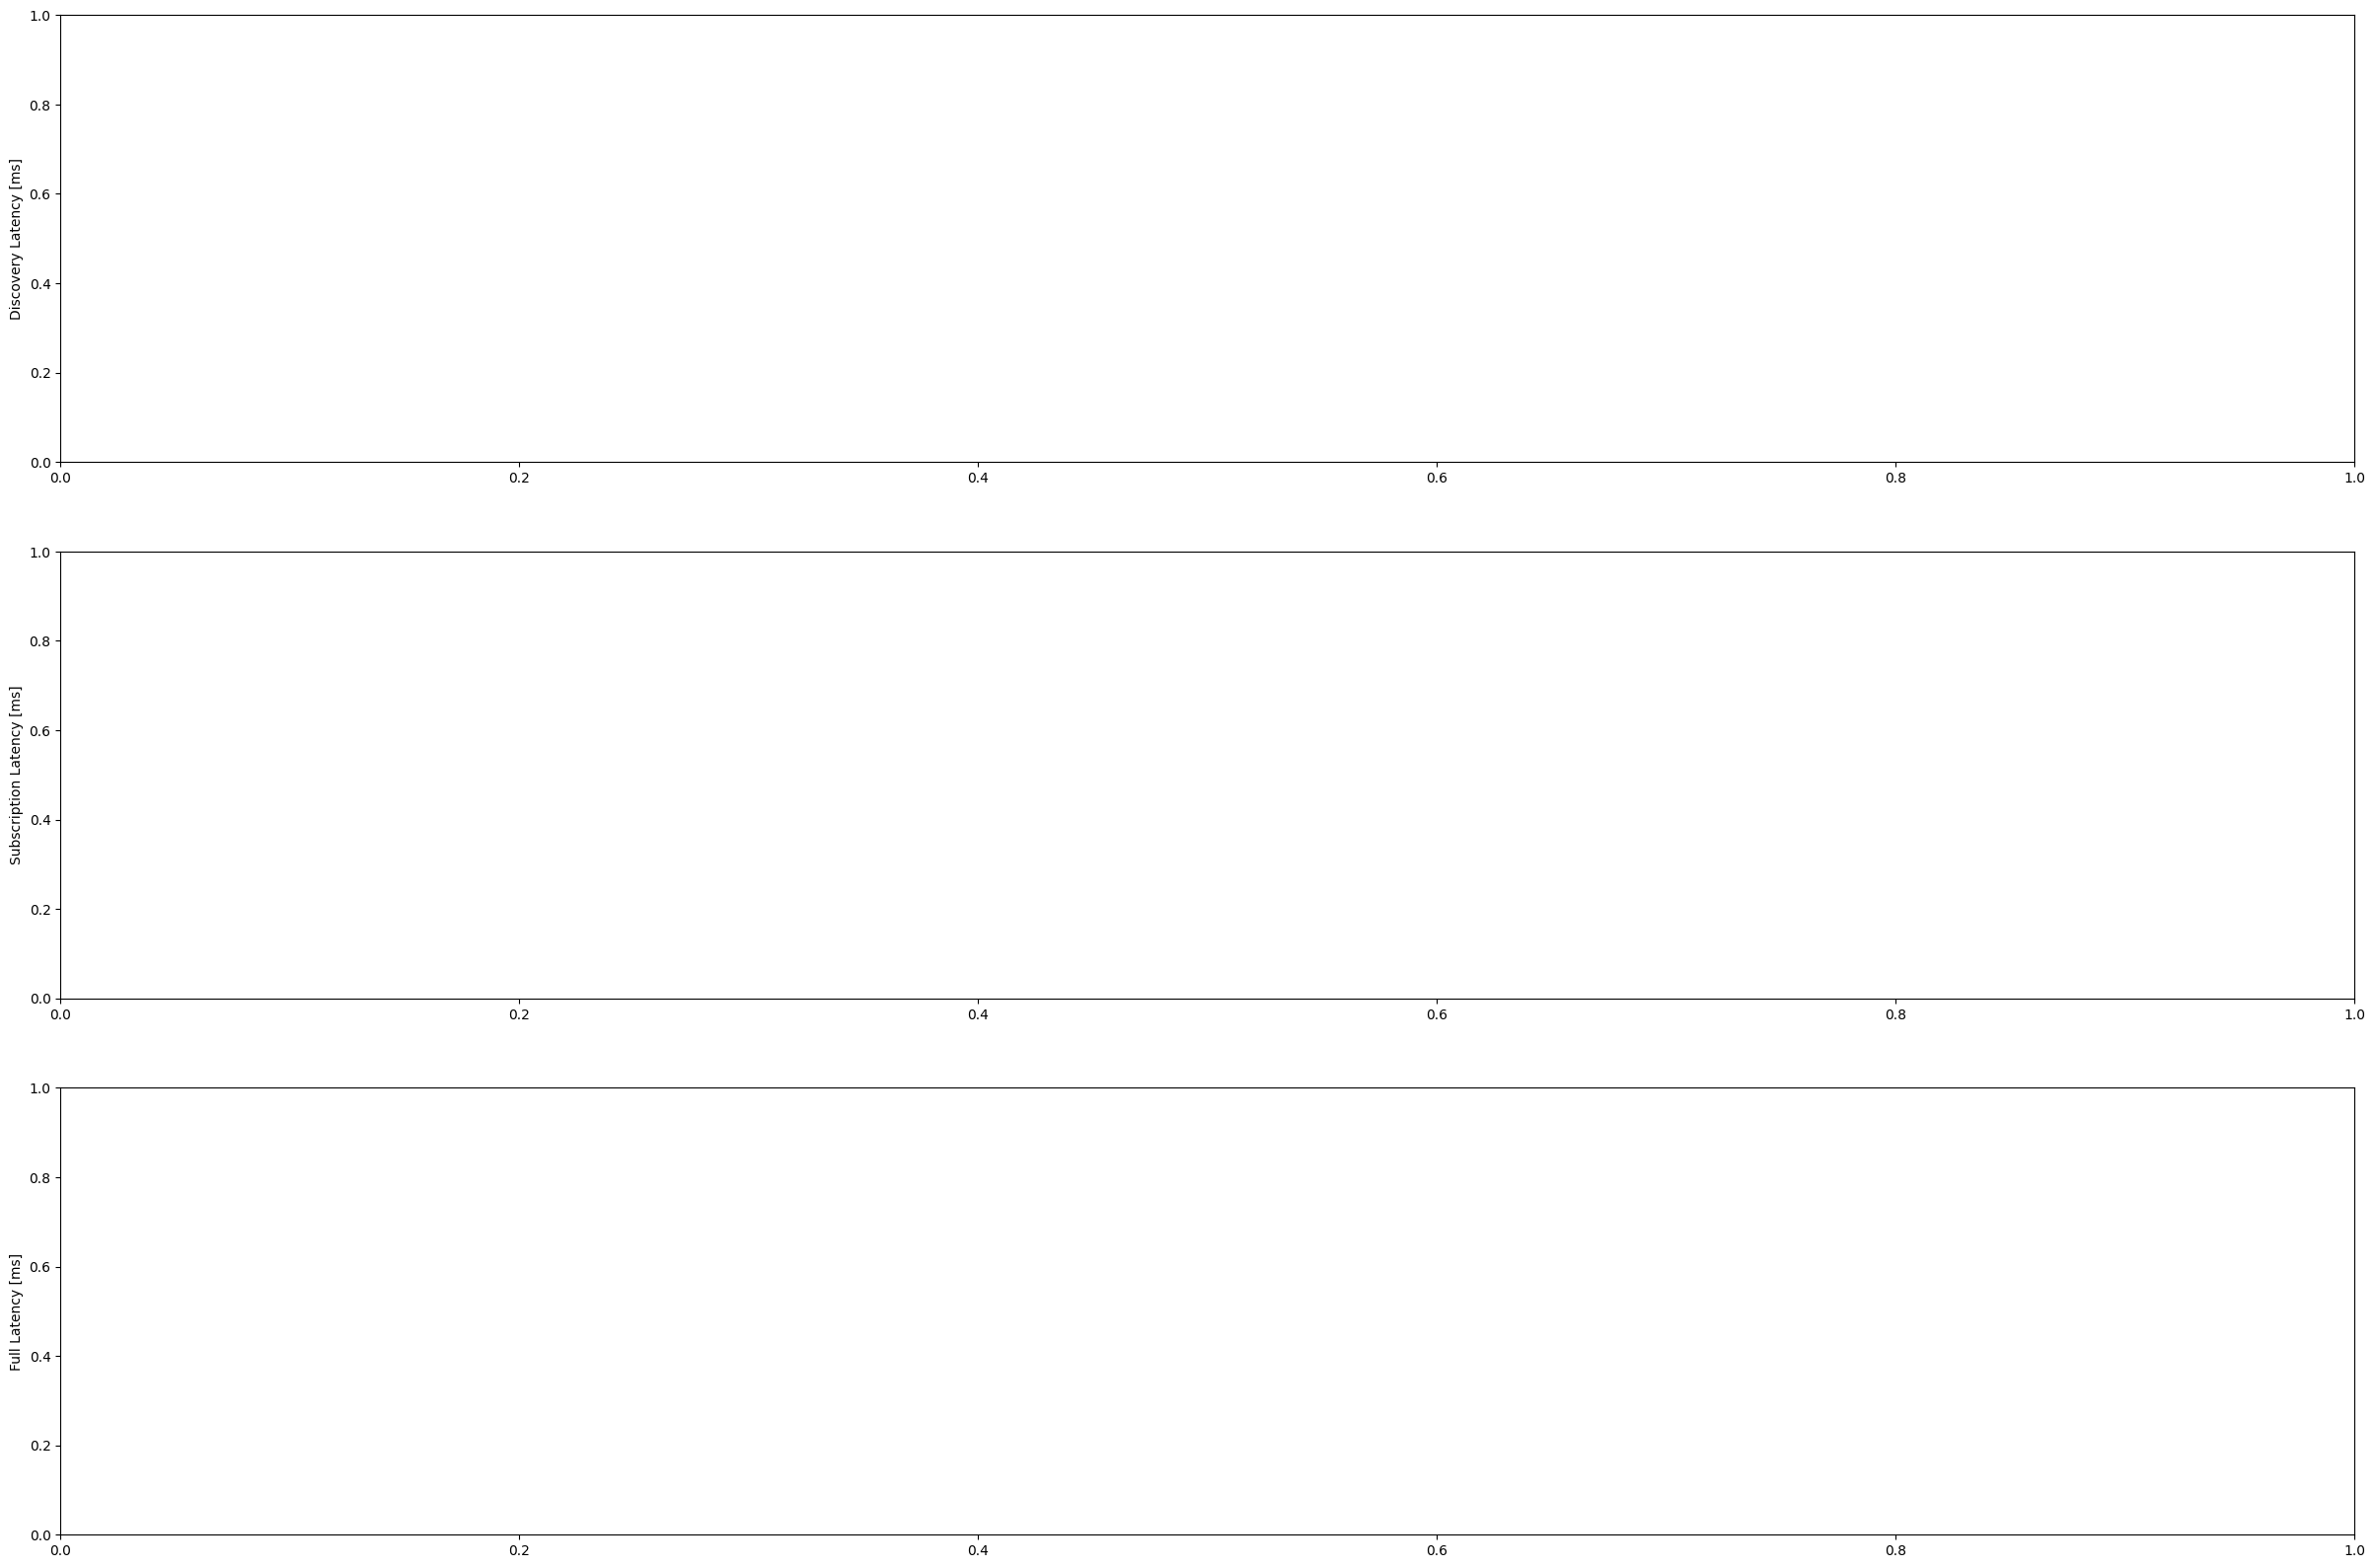

In [7]:
# # SUB_PATH='1xpublisher-1xsubscriber'
# SUB_PATH='1xpublisher-1xsubscriber-wo-any-delaycm'
# discovery_latency_dict: dict = dict()
# subscription_latency_dict: dict = dict()
# full_latency_dict: dict = dict()
# fig, ax = plt.subplots(3, 1, figsize=(30, 20))
# title: str = ''
# box_labels: list = list()

# ax[0].set_ylabel('Discovery Latency [ms]')
# ax[1].set_ylabel('Subscription Latency [ms]')
# ax[2].set_ylabel('Full Latency [ms]')

# for option, description in compile_definitions.items():
#     evaluation_option = option
#     member_count = 1
#     description_list = description.split()
#     box_labels.append(option+'\n'+'\n'.join(description_list))
#     discovery_latency: list = list()
#     subscription_latency: list = list()
#     full_latency: list = list()
#     for file_count in range(0,50):
#         filename = f'{STATISTICS_PARENT_PATH}/{SUB_PATH}/{evaluation_option}-{member_count}-#{file_count}.csv'
#         df = pd.read_csv(filepath_or_buffer=filename, header=0, sep=',', dtype=np.longlong)
#         if NO_SOMEIP_SD in description:
#             discovery_upper_bound = df['SVCB_SERVICE_RESPONSE_RECEIVE'].max()/1000_000
#             subscription_lower_bound = df['SVCB_SERVICE_RESPONSE_RECEIVE'].min()/1000_000
#         else:
#             discovery_upper_bound = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1)).max()/1000_000
#             subscription_lower_bound = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1)).min()/1000_000
#         if WITH_SERVICE_AUTHENTICATION in description:
#             subscription_upper_bound = df['VERIFY_SERVICE_SIGNATURE_END'].max()/1000_000
#         else:
#             subscription_upper_bound = df['SUBSCRIBE_ACK_RECEIVE'].max()/1000_000
#         discovery_latency.append(discovery_upper_bound - df['SUBSCRIBER_APP_INITIALIZATION_END'].min()/1000_000)
#         subscription_latency.append(subscription_upper_bound - subscription_lower_bound)
#         full_latency.append(subscription_upper_bound - df['SUBSCRIBER_APP_INITIALIZATION_END'].min()/1000_000)
#     discovery_latency_dict[option] = discovery_latency
#     subscription_latency_dict[option] = subscription_latency
#     full_latency_dict[option] = full_latency
#     df_discovery_latency = pd.DataFrame()
#     df_subscription_latency = pd.DataFrame()
#     df_full_latency = pd.DataFrame()
#     df_discovery_latency['DISCOVERY_LATENCY'] = discovery_latency
#     df_subscription_latency['SUBSCRIPTION_LATENCY'] = subscription_latency
#     df_full_latency['FULL_LATENCY'] = full_latency
#     df_discovery_latency.to_csv(f'export/{SUB_PATH}/{option}-{member_count}-DISCOVERY-LATENCY.csv', index=False)
#     df_subscription_latency.to_csv(f'export/{SUB_PATH}/{option}-{member_count}-SUBSCRIPTION-LATENCY.csv', index=False)
#     df_full_latency.to_csv(f'export/{SUB_PATH}/{option}-{member_count}-FULL-LATENCY.csv', index=False)

# ax[0].boxplot(discovery_latency_dict.values())
# ax[0].set_xticklabels(labels=box_labels, rotation=0)
# ax[1].boxplot(subscription_latency_dict.values())
# ax[1].set_xticklabels(labels=box_labels, rotation=0)
# ax[2].boxplot(full_latency_dict.values())
# ax[2].set_xticklabels(labels=box_labels, rotation=0)
# ax[0].set_ylim(ymin=0, ymax=40)
# ax[1].set_ylim(ymin=0, ymax=40)
# ax[2].set_ylim(ymin=0, ymax=40)
# plt.subplots_adjust(hspace=0.4)
# plt.show()

## Plot Given Option w/ 1xPublisher and NxSubscribers

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\phili\\OneDrive\\paper_dnssec_autho_data\\statistic-results/G-series/G-1-#0.csv'

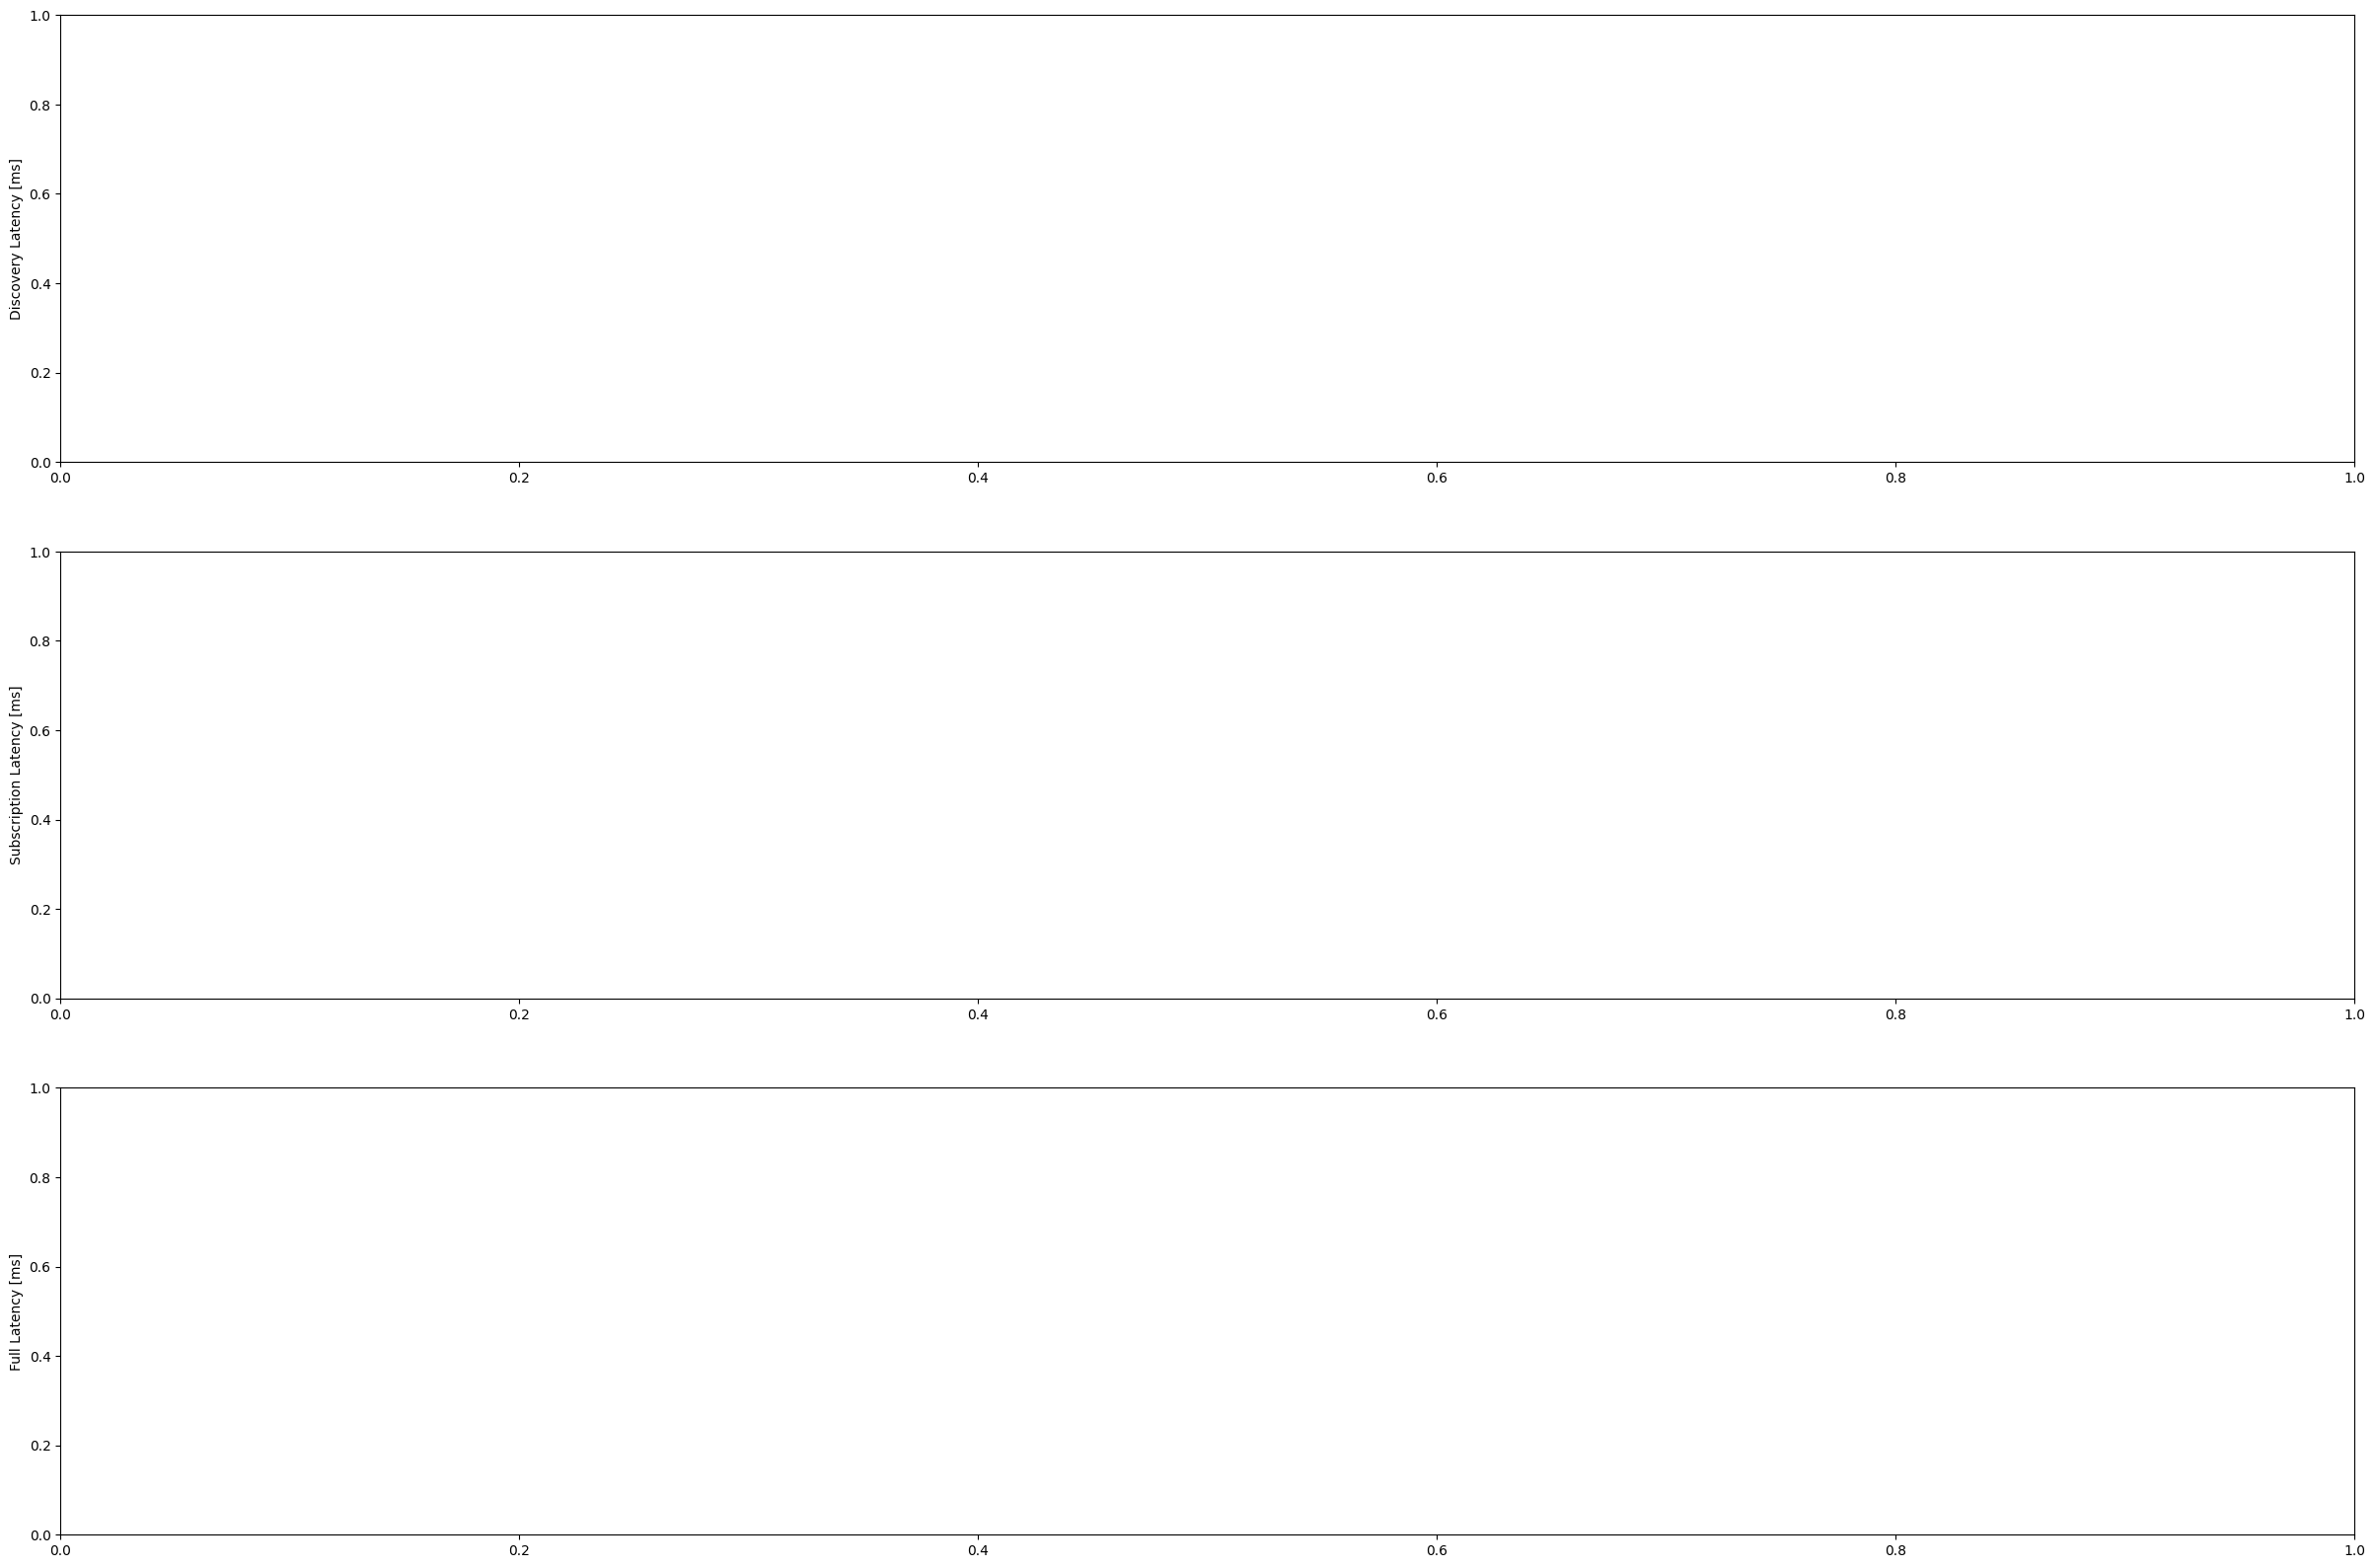

In [8]:
# fig, ax = plt.subplots(3, 1, figsize=(30, 20))
# ax[0].set_ylabel('Discovery Latency [ms]')
# ax[1].set_ylabel('Subscription Latency [ms]')
# ax[2].set_ylabel('Full Latency [ms]')

# option = 'G'
# description = compile_definitions[option]

# discovery_latency_dict: dict = dict()
# subscription_latency_dict: dict = dict()
# full_latency_dict: dict = dict()
# member_count_axis: list = list()
# for member_count in range(0,151):
#     if member_count == 0:
#         continue
#     member_count_axis.append(member_count)
#     discovery_latency: list = list()
#     subscription_latency: list = list()
#     full_latency: list = list()
#     for file_count in range(0,50):
#         filename = f'{STATISTICS_PARENT_PATH}/{option}-series/{option}-{member_count}-#{file_count}.csv'
#         df = pd.read_csv(filepath_or_buffer=filename, header=0, sep=',', dtype=np.longlong)
#         if NO_SOMEIP_SD in description:
#             discovery_upper_bound = df['SVCB_SERVICE_RESPONSE_RECEIVE'].max()/1000_000
#             subscription_lower_bound = df['SVCB_SERVICE_RESPONSE_RECEIVE'].min()/1000_000
#         else:
#             discovery_upper_bound = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1)).max()/1000_000
#             subscription_lower_bound = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1)).min()/1000_000
#         if WITH_SERVICE_AUTHENTICATION in description:
#             subscription_upper_bound = df['VERIFY_SERVICE_SIGNATURE_END'].max()/1000_000
#         else:
#             subscription_upper_bound = df['SUBSCRIBE_ACK_RECEIVE'].max()/1000_000
#         discovery_latency.append(discovery_upper_bound - df['SUBSCRIBER_APP_INITIALIZATION_END'].min()/1000_000)
#         subscription_latency.append(subscription_upper_bound - subscription_lower_bound)
#         full_latency.append(subscription_upper_bound - df['SUBSCRIBER_APP_INITIALIZATION_END'].min()/1000_000)
#     discovery_latency_dict[member_count] = discovery_latency
#     subscription_latency_dict[member_count] = subscription_latency
#     full_latency_dict[member_count] = full_latency
#     df_discovery_latency = pd.DataFrame()
#     df_subscription_latency = pd.DataFrame()
#     df_full_latency = pd.DataFrame()
#     df_discovery_latency['DISCOVERY_LATENCY'] = discovery_latency
#     df_subscription_latency['SUBSCRIPTION_LATENCY'] = subscription_latency
#     df_full_latency['FULL_LATENCY'] = full_latency
#     df_discovery_latency.to_csv(f'export/{option}/{option}-{member_count}-DISCOVERY-LATENCY.csv', index=False)
#     df_subscription_latency.to_csv(f'export/{option}/{option}-{member_count}-SUBSCRIPTION-LATENCY.csv', index=False)
#     df_full_latency.to_csv(f'export/{option}/{option}-{member_count}-FULL-LATENCY.csv', index=False)

# ax[0].boxplot(discovery_latency_dict.values())
# ax[0].set_xticklabels(labels=member_count_axis, rotation=0)
# ax[0].set_xlabel("Subscriber Count[#]")
# ax[0].yaxis.grid(True)

# ax[1].boxplot(subscription_latency_dict.values())
# ax[1].set_xticklabels(labels=member_count_axis, rotation=0)
# ax[1].set_xlabel("Subscriber Count[#]")
# ax[1].yaxis.grid(True)

# ax[2].boxplot(full_latency_dict.values())
# ax[2].set_xticklabels(labels=member_count_axis, rotation=0)
# ax[2].set_xlabel("Subscriber Count[#]")
# ax[2].yaxis.grid(True)
# plt.show()

## Check the Likeliness If OFFER Messages Arrive Earlier Than SVCB Responses

In [11]:
option = 'G'
found_rows_list: list = list()
for member_count in range(1,151):
    for file_count in range(0,50):
        filename = f'{STATISTICS_PARENT_PATH}/{option}-series/{option}-{member_count}-#{file_count}.csv'
        df = pd.read_csv(filepath_or_buffer=filename, header=0, sep=',', dtype=np.longlong)
        found_rows = len(df[df['SVCB_SERVICE_RESPONSE_RECEIVE'] > df['OFFER_RECEIVE']])
        if found_rows:
            found_rows_list.append(found_rows)
            #print(f'found in {option}-{member_count}-#{file_count}.csv')
print(f'Maximum rows in one file {max(found_rows_list)}')
print(len(found_rows_list))
print(found_rows_list)

Maximum rows in one file 4
133
[1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 3, 2]


In [9]:
# option = 'G'
# member_count = 33
# file_count = 37
# filename = f'{STATISTICS_PARENT_PATH}/{option}-series/{option}-{member_count}-#{file_count}.csv'
# df = pd.read_csv(filepath_or_buffer=filename, header=0, sep=',', dtype=np.longlong)
# df[df['SVCB_SERVICE_RESPONSE_RECEIVE'] > df['OFFER_RECEIVE']]

,HOST,PUBLISHER_APP_INITIALIZATION,SUBSCRIBER_APP_INITIALIZATION_START,SUBSCRIBER_APP_INITIALIZATION_END,GENERATE_OFFER_NONCE_START,GENERATE_OFFER_NONCE_END,FIND_SEND,FIND_RECEIVE,OFFER_SEND,OFFER_RECEIVE,...,SERVICE_SIGN_START,SERVICE_SIGN_END,SUBSCRIBE_ACK_SEND,SUBSCRIBE_ACK_RECEIVE,TLSA_SERVICE_REQUEST_SEND,TLSA_SERVICE_REQUEST_RECEIVE,TLSA_SERVICE_RESPONSE_SEND,TLSA_SERVICE_RESPONSE_RECEIVE,VERIFY_SERVICE_SIGNATURE_START,VERIFY_SERVICE_SIGNATURE_END
22,167772184,0,1707523319883597173,1707523319884707897,0,0,1707523319899612510,0,0,1707523319901074723,...,1707523319912618082,1707523319913392676,1707523319913393580,1707523319913595741,1707523319904957529,0,0,1707523319907998673,1707523319909105163,1707523319913859386


## Plot Latencies for All Samples for a Certain Member Count and Option

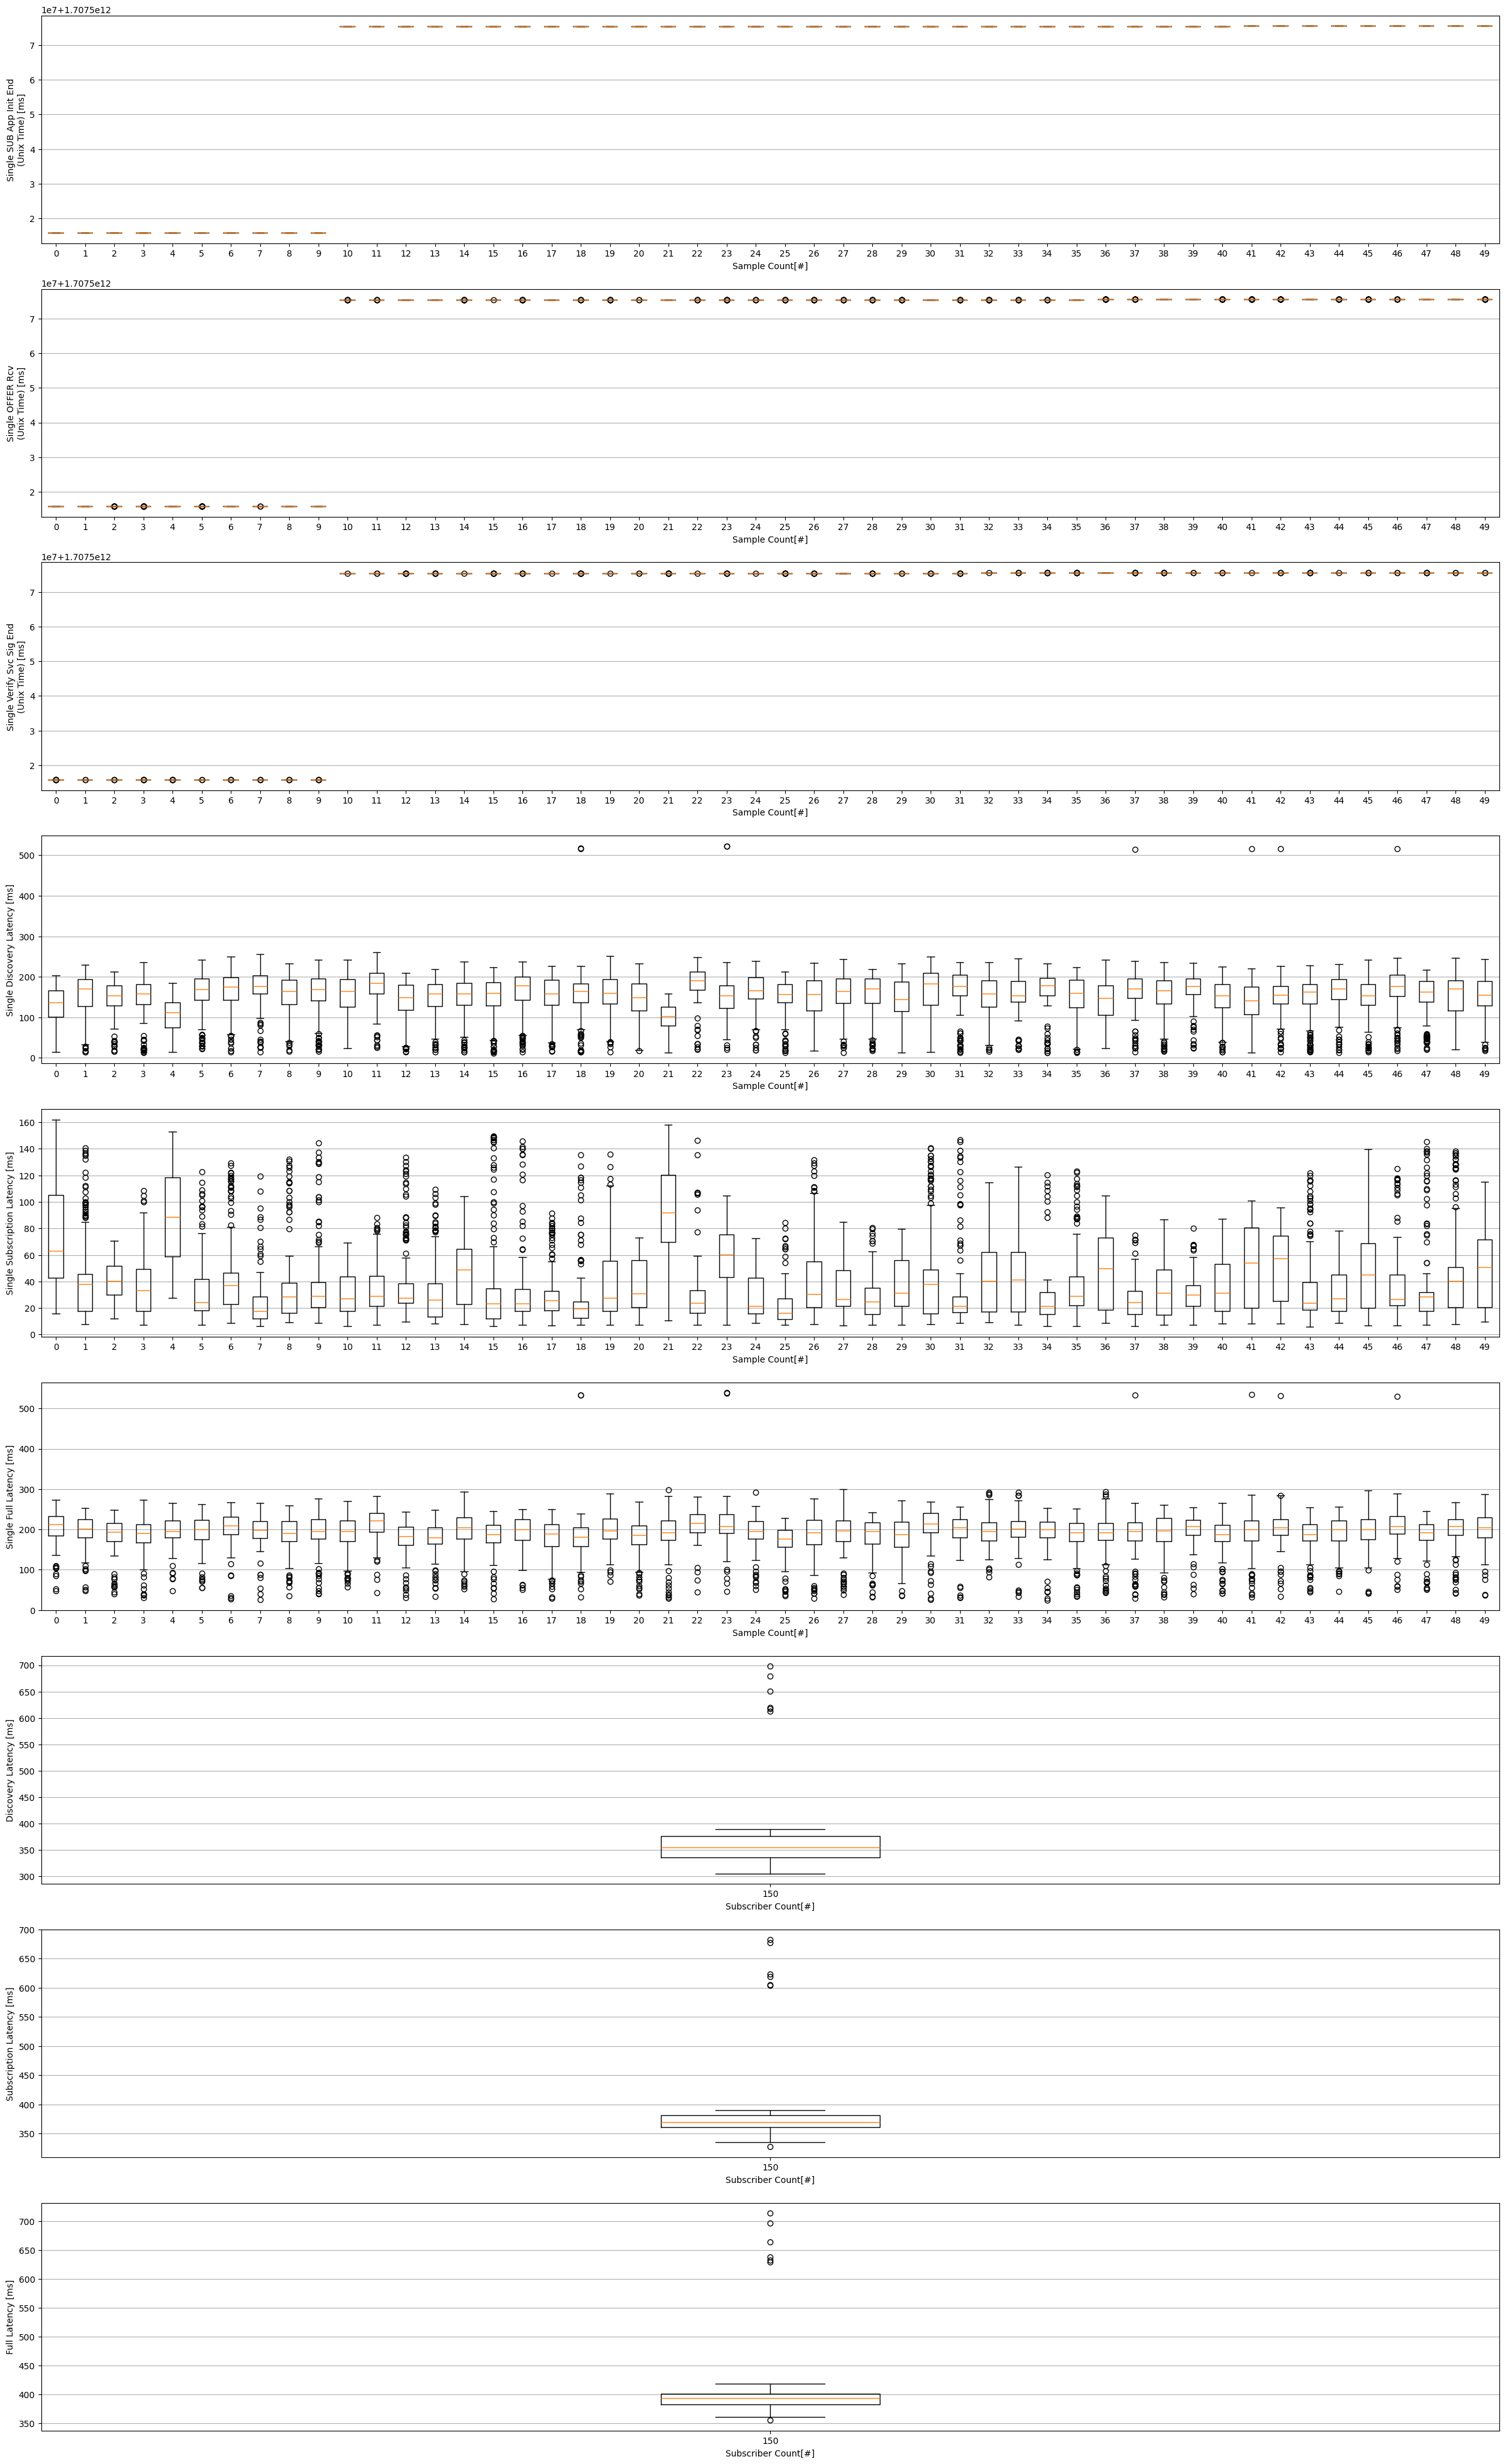

In [79]:
# fig, ax = plt.subplots(9, 1, figsize=(30, 50))
# ax[0].set_ylabel('Single SUB App Init End\n(Unix Time) [ms]')
# ax[1].set_ylabel('Single OFFER Rcv\n(Unix Time) [ms]')
# ax[2].set_ylabel('Single Verify Svc Sig End\n(Unix Time) [ms]')
# ax[3].set_ylabel('Single Discovery Latency [ms]')
# ax[4].set_ylabel('Single Subscription Latency [ms]')
# ax[5].set_ylabel('Single Full Latency [ms]')
# ax[6].set_ylabel('Discovery Latency [ms]')
# ax[7].set_ylabel('Subscription Latency [ms]')
# ax[8].set_ylabel('Full Latency [ms]')

# option = 'H'
# member_count = 150
# single_subscriber_app_initialization_end_dict: dict = dict()
# single_offer_receive_dict: dict = dict()
# single_verify_service_signature_end_dict: dict = dict()
# single_discovery_latency_dict: dict = dict()
# single_subscription_latency_dict: dict = dict()
# single_full_latency_dict: dict = dict()
# discovery_latency_list: list = list()
# subscription_latency_list: list = list()
# full_latency_list: list = list()
# for sample_count in range(0,50):
#     filename = f'{STATISTICS_PARENT_PATH}/{option}-series/{option}-{member_count}-#{sample_count}.csv'
#     df = pd.read_csv(filepath_or_buffer=filename, header=0, sep=',', dtype=np.longlong)
#     single_subscriber_app_initialization_end_dict[sample_count] = df['SUBSCRIBER_APP_INITIALIZATION_END']/1000_000
#     single_offer_receive_dict[sample_count] = df['OFFER_RECEIVE']/1000_000
#     single_verify_service_signature_end_dict[sample_count] = df['VERIFY_SERVICE_SIGNATURE_END']/1000_000
#     single_discovery_latency_dict[sample_count] = (df['OFFER_RECEIVE'] -  df['SUBSCRIBER_APP_INITIALIZATION_END'])/1000_000
#     single_subscription_latency_dict[sample_count] = (df['VERIFY_SERVICE_SIGNATURE_END'] - df['OFFER_RECEIVE'])/1000_000
#     single_full_latency_dict[sample_count] = (df['VERIFY_SERVICE_SIGNATURE_END'] - df['SUBSCRIBER_APP_INITIALIZATION_END'])/1000_000
#     discovery_upper_bound = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1)).max()
#     discovery_latency_list.append((discovery_upper_bound - df['SUBSCRIBER_APP_INITIALIZATION_END'].min())/1000_000)
#     subscription_lower_bound = (df[['OFFER_RECEIVE', 'SVCB_SERVICE_RESPONSE_RECEIVE']].max(axis=1)).min()
#     subscription_latency_list.append((df['VERIFY_SERVICE_SIGNATURE_END'].max() - subscription_lower_bound)/1000_000 )
#     full_latency_list.append((df['VERIFY_SERVICE_SIGNATURE_END'].max() - df['SUBSCRIBER_APP_INITIALIZATION_END'].min())/1000_000)
#     # print(f'Full Latency - {option}-{member_count}-#{sample_count}: ' + str((df['VERIFY_SERVICE_SIGNATURE_END'].max() - df['SUBSCRIBER_APP_INITIALIZATION_END'].min())/1000_000) + 'ms')

# ax[0].boxplot(single_subscriber_app_initialization_end_dict.values())
# ax[0].set_xticklabels(labels=single_subscriber_app_initialization_end_dict.keys(), rotation=0)
# ax[0].set_xlabel("Sample Count[#]")
# ax[0].yaxis.grid(True)

# ax[1].boxplot(single_offer_receive_dict.values())
# ax[1].set_xticklabels(labels=single_offer_receive_dict.keys(), rotation=0)
# ax[1].set_xlabel("Sample Count[#]")
# ax[1].yaxis.grid(True)

# ax[2].boxplot(single_verify_service_signature_end_dict.values())
# ax[2].set_xticklabels(labels=single_verify_service_signature_end_dict.keys(), rotation=0)
# ax[2].set_xlabel("Sample Count[#]")
# ax[2].yaxis.grid(True)

# ax[3].boxplot(single_discovery_latency_dict.values())
# ax[3].set_xticklabels(labels=single_discovery_latency_dict.keys(), rotation=0)
# ax[3].set_xlabel("Sample Count[#]")
# ax[3].yaxis.grid(True)

# ax[4].boxplot(single_subscription_latency_dict.values())
# ax[4].set_xticklabels(labels=single_subscription_latency_dict.keys(), rotation=0)
# ax[4].set_xlabel("Sample Count[#]")
# ax[4].yaxis.grid(True)

# ax[5].boxplot(single_full_latency_dict.values())
# ax[5].set_xticklabels(labels=single_full_latency_dict.keys(), rotation=0)
# ax[5].set_xlabel("Sample Count[#]")
# ax[5].yaxis.grid(True)

# ax[6].boxplot(discovery_latency_list)
# ax[6].set_xticklabels(labels=[member_count], rotation=0)
# ax[6].set_xlabel("Subscriber Count[#]")
# ax[6].yaxis.grid(True)

# ax[7].boxplot(subscription_latency_list)
# ax[7].set_xticklabels(labels=[member_count], rotation=0)
# ax[7].set_xlabel("Subscriber Count[#]")
# ax[7].yaxis.grid(True)

# ax[8].boxplot(full_latency_list)
# ax[8].set_xticklabels(labels=[member_count], rotation=0)
# ax[8].set_xlabel("Subscriber Count[#]")
# ax[8].yaxis.grid(True)
# # plt.subplots_adjust(hspace=0.4)
# plt.show()

In [7]:
# Assuming df is your DataFrame
# Example DataFrame creation
data = {'OFFER_RECEIVE': [10, 20, 30],
        'SVCB_RECEIVE': [25, 15, 35]}
df = pd.DataFrame(data)

# Find the maximum value among the maximum values of each row
overall_max = (df[['OFFER_RECEIVE', 'SVCB_RECEIVE']].max(axis=1)).max()
max_offer = df['OFFER_RECEIVE'].max()
max_svcb = df['SVCB_RECEIVE'].max()
dbg_max = df[['OFFER_RECEIVE', 'SVCB_RECEIVE']].max(axis=1)

print("Maximum value among all rows:", overall_max)
print("Other approach", max(max_offer,max_svcb))

Maximum value among all rows: 35
Other approach 35
